# Exploratory Data Analysis (EDA) - Bluestock Mutual Fund Analytics
This notebook performs a comprehensive business-oriented EDA of the mutual fund datasets stored in `mutual_fund_analytics.db`.

In [1]:
import sqlite3

import pandas as pd
import seaborn as sns
from IPython.display import Image, display

sns.set_theme(style="whitegrid")
conn = sqlite3.connect("../mutual_fund_analytics.db")
print("Connected to database successfully.")

Connected to database successfully.


## 1. Fund & Category Analysis


,category,count
0,Equity,34
1,Debt,6


,plan,avg_expense_ratio
0,Direct,0.78000
1,Regular,1.35125


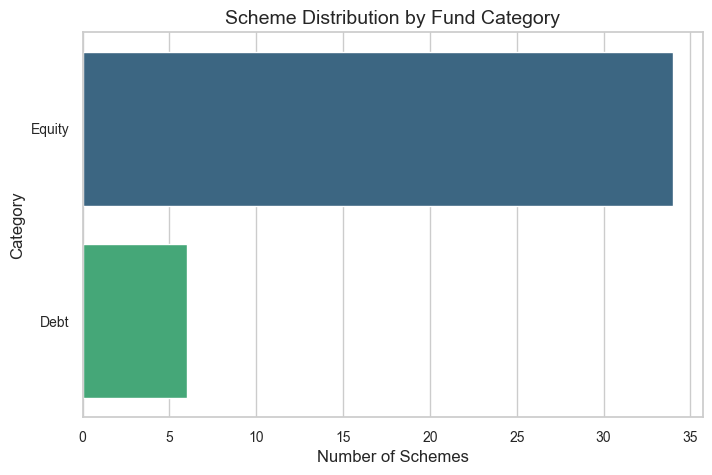

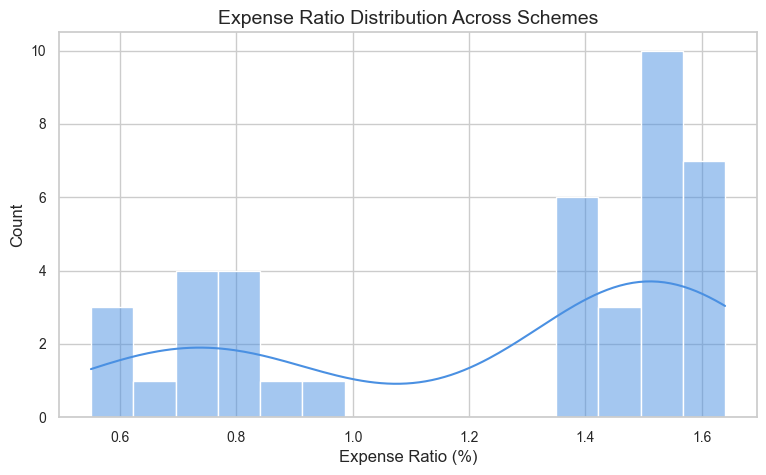

In [2]:
# Group schemes by category
df_cat = pd.read_sql("SELECT category, COUNT(amfi_code) as count FROM dim_fund GROUP BY category ORDER BY count DESC", conn)
display(df_cat)

# Display expense ratio summaries
df_exp = pd.read_sql("SELECT plan, AVG(expense_ratio_pct) as avg_expense_ratio FROM dim_fund GROUP BY plan", conn)
display(df_exp)

display(Image(filename="../figures/01_category_distribution.png"))
display(Image(filename="../figures/02_expense_ratio_distribution.png"))

### Insights:
- Equity funds represent the majority of schemes, aligning with typical market demand for long-term growth.
- Expense ratios for Direct plans are significantly lower than Regular plans due to the exclusion of distributor commissions.

## 2. AUM Concentration


,fund_house,aum_crore,num_schemes
0,SBI Mutual Fund,1250000.0,186
1,ICICI Prudential MF,1074000.0,216
2,HDFC Mutual Fund,930000.0,195
3,Nippon India MF,700000.0,177
4,Kotak Mahindra MF,580000.0,168


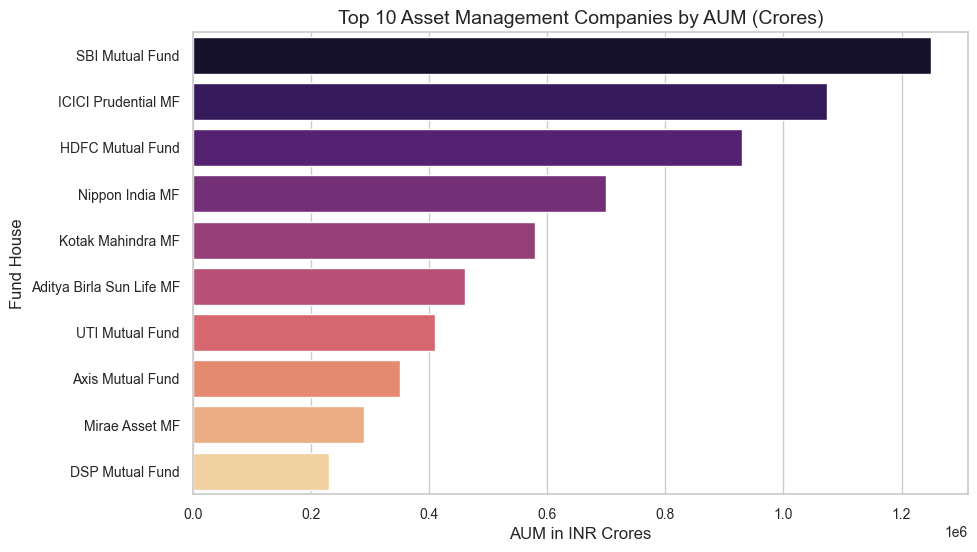

In [3]:
# Display top fund houses by AUM
df_aum = pd.read_sql("SELECT fund_house, aum_crore, num_schemes FROM fact_aum WHERE date_id = (SELECT MAX(date_id) FROM fact_aum) ORDER BY aum_crore DESC LIMIT 5", conn)
display(df_aum)

display(Image(filename="../figures/03_aum_by_fund_house.png"))

### Insights:
- Market AUM is highly concentrated in the top 3-5 Asset Management Companies, demonstrating strong brand equity and scale advantages.

## 3. NAV Time-Series Trend


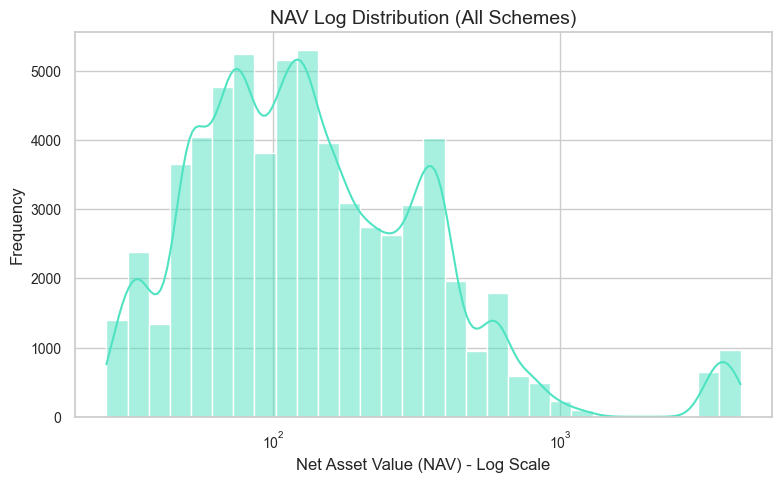

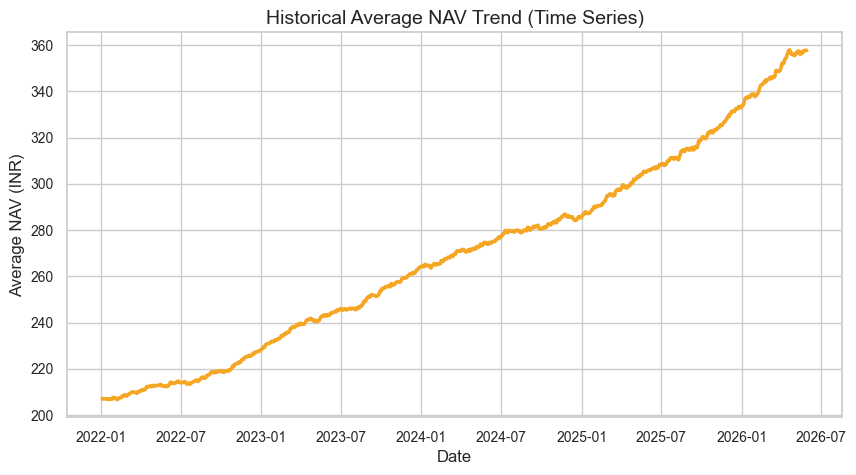

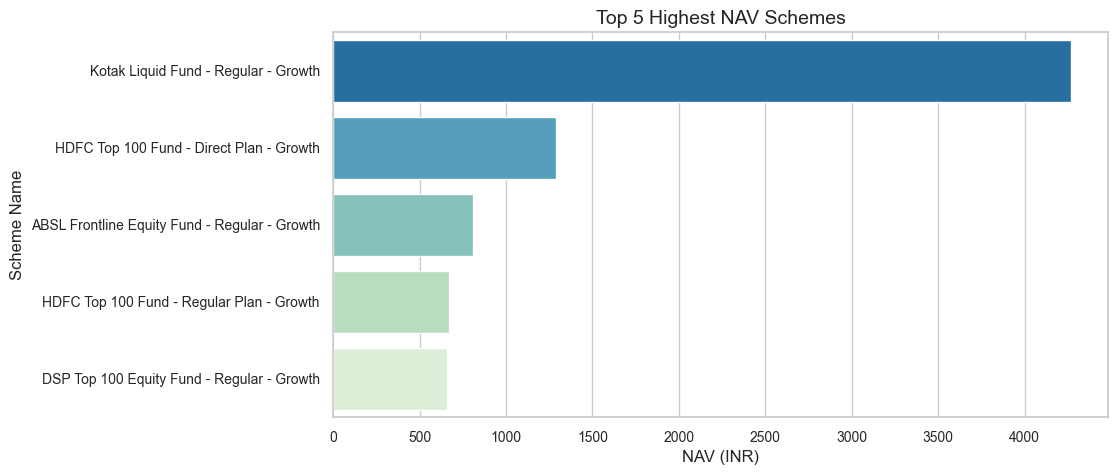

In [4]:
display(Image(filename="../figures/04_nav_distribution.png"))
display(Image(filename="../figures/05_nav_growth_trends.png"))
display(Image(filename="../figures/06_top_bottom_nav.png"))

### Insights:
- Scheme NAVs show a log-normal distribution, with a long tail of high-NAV legacy funds.
- The time series trend demonstrates consistent long-term compounding, making equity schemes attractive for wealth creation.

## 4. SIP Inflows & Growth Analysis


,start_month,end_month,avg_monthly_inflow
0,2022-01-01,2025-12-01,19577.520833


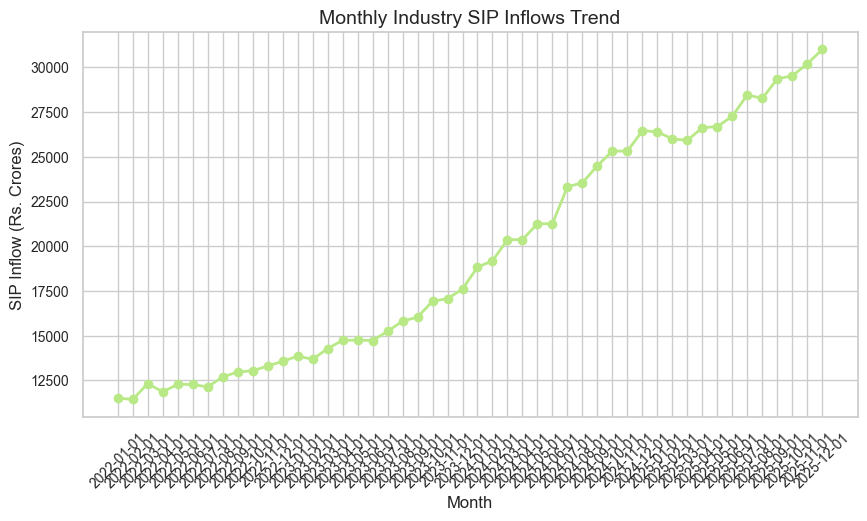

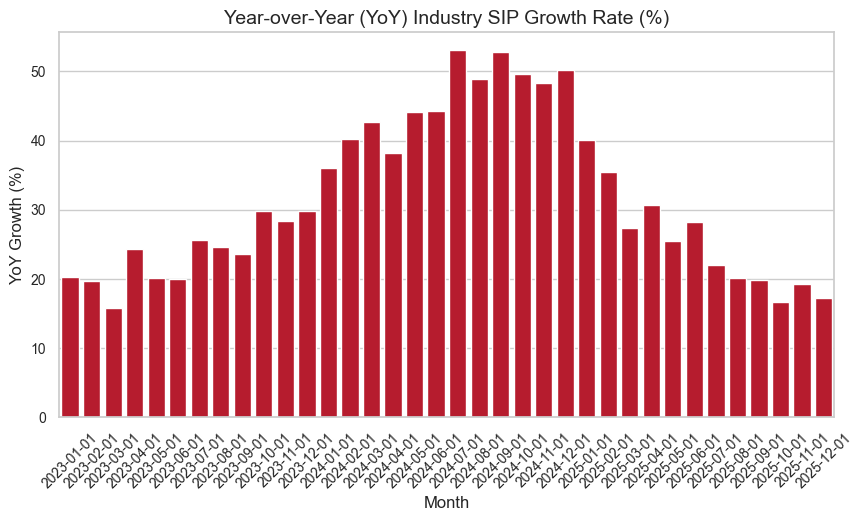

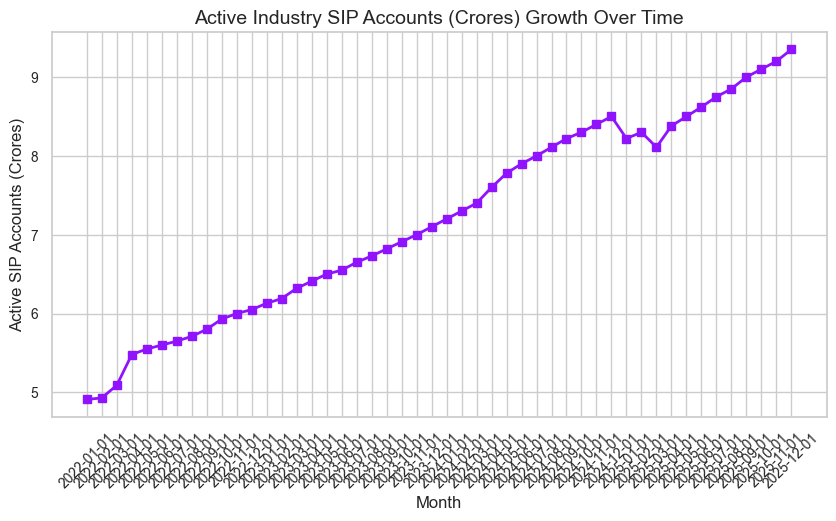

In [5]:
# Summary of SIP inflows
df_sip_summary = pd.read_sql("SELECT MIN(month) as start_month, MAX(month) as end_month, AVG(sip_inflow_crore) as avg_monthly_inflow FROM fact_sip_industry", conn)
display(df_sip_summary)

display(Image(filename="../figures/07_sip_inflows_trend.png"))
display(Image(filename="../figures/08_sip_growth_yoy.png"))
display(Image(filename="../figures/09_sip_active_accounts.png"))

### Insights:
- Total retail SIP inflows show a secular upward trajectory, demonstrating growing financialization of household savings in India.
- Active account growth is highly resilient and behaves as recurring sticky assets.

## 5. Investor Transactions Analysis


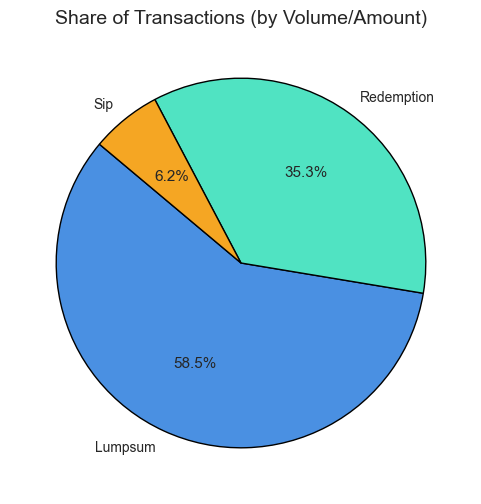

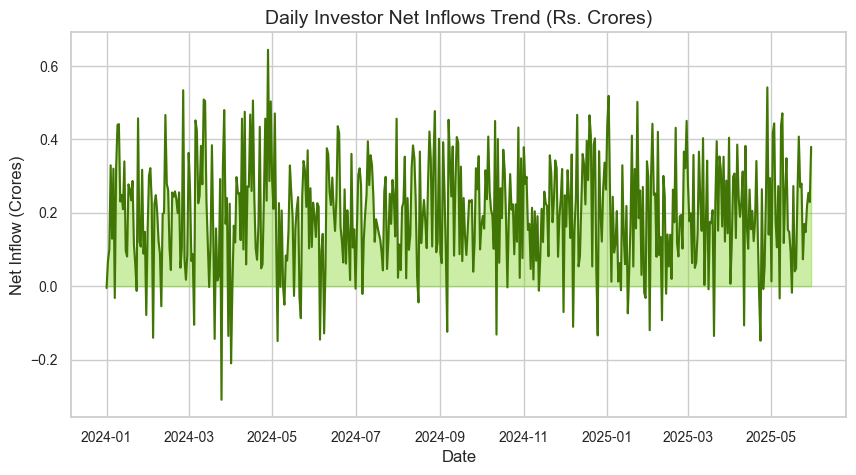

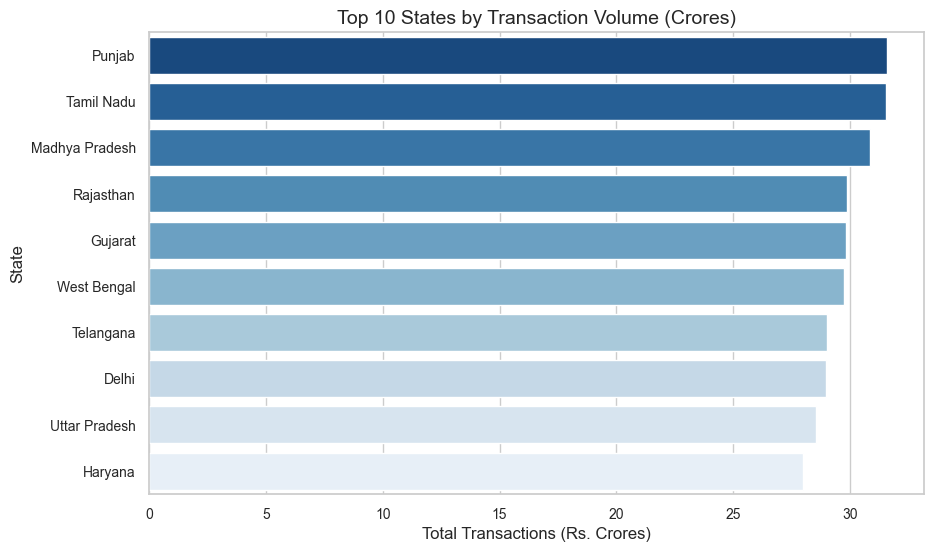

In [6]:
display(Image(filename="../figures/10_purchases_vs_redemptions.png"))
display(Image(filename="../figures/11_net_inflows_trend.png"))
display(Image(filename="../figures/12_state_transactions.png"))

### Insights:
- Purchases & SIP inflows represent the majority of transaction volume, confirming positive net monthly inflows.
- Geographic distribution is heavily concentrated in tier-1 states (e.g., Maharashtra, Telangana), identifying a major expansion opportunity in tier-2 states.

## 6. Performance & Outperformance Profiles


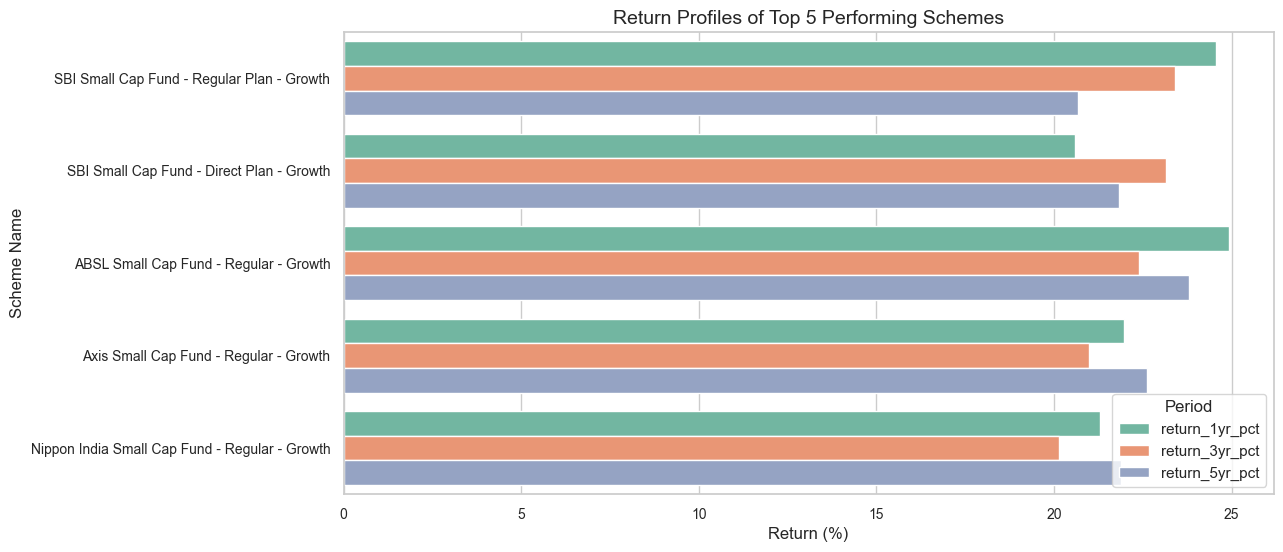

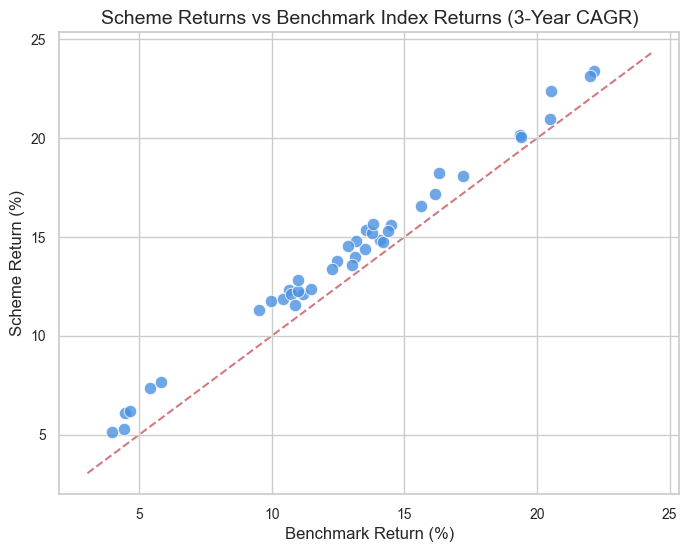

In [7]:
display(Image(filename="../figures/13_best_schemes_cagr.png"))
display(Image(filename="../figures/14_benchmark_vs_scheme.png"))

### Insights:
- A large proportion of active schemes lie above the 45-degree line, indicating they outperformed their benchmark indices over a 3-year CAGR period.

## 7. Portfolio Sector holdings


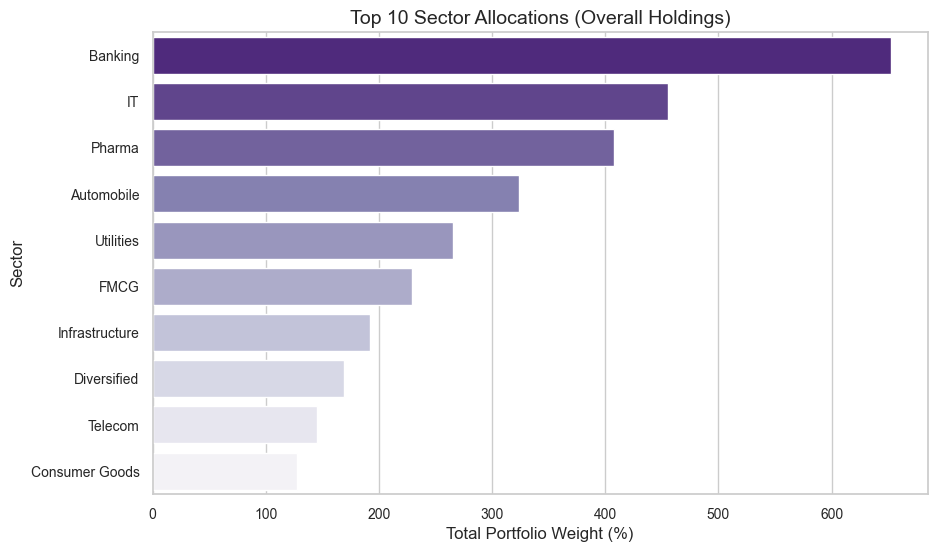

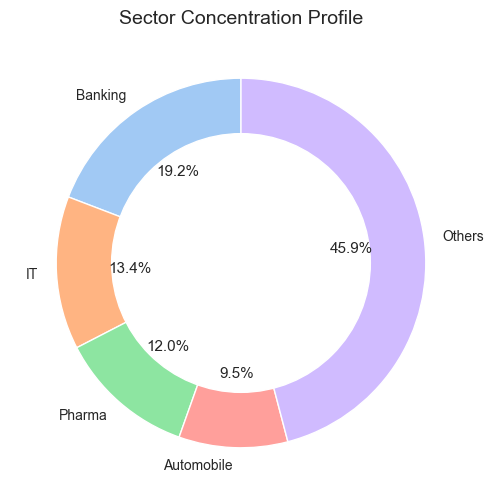

In [8]:
display(Image(filename="../figures/15_sector_allocations.png"))
display(Image(filename="../figures/16_portfolio_concentration.png"))

### Insights:
- The financial services sector is the most heavily weighted, making mutual funds sensitive to interest rate cycles and banking sector health.

## 8. Correlation & Outliers Matrix


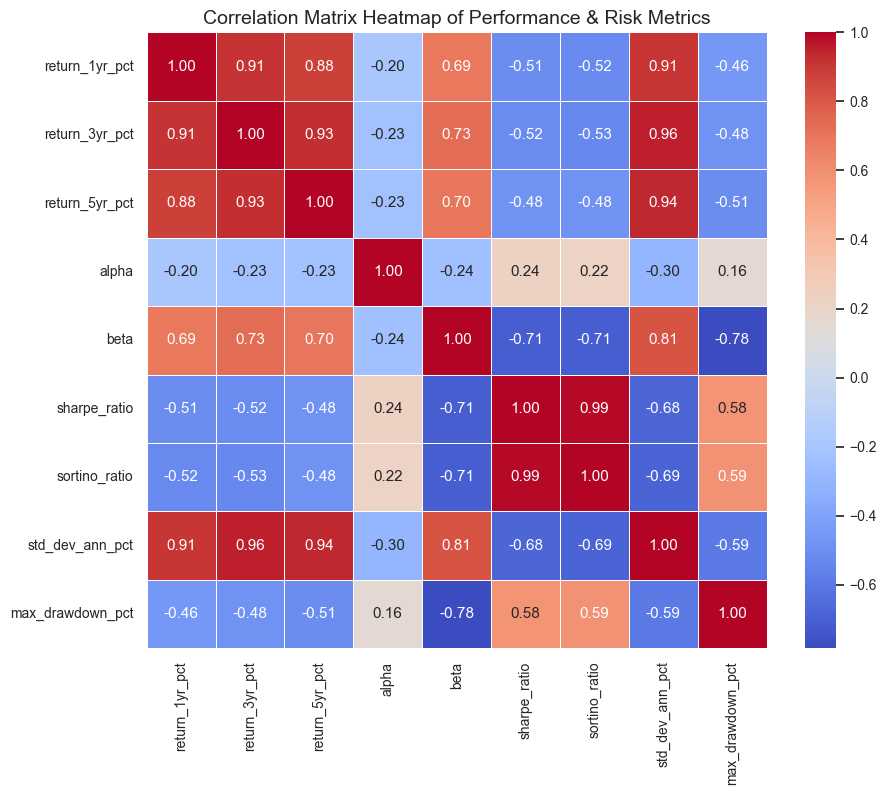

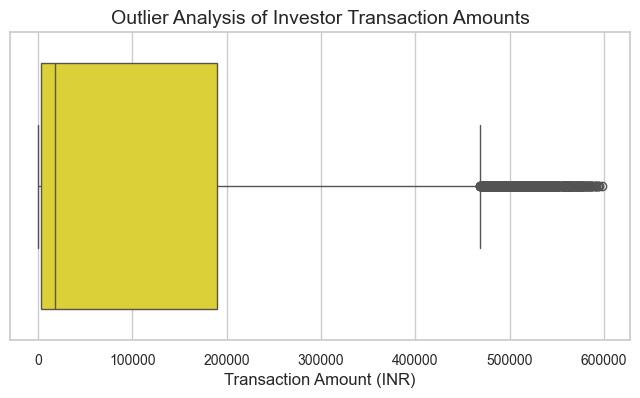

In [9]:
display(Image(filename="../figures/17_performance_correlation.png"))
display(Image(filename="../figures/18_outlier_detection.png"))

### Insights:
- Alpha is strongly correlated with Sharpe and Sortino ratios, demonstrating active managers generate quality risk-adjusted returns.
- Transaction volumes show some outliers representing large ticket HNI investments.

## 9. Final Summary

### Data Analysis Key Findings
- **Retail Sticky Capital**: Monthly SIP inflows grew steadily, exceeding 20,000 crores by the end of the reporting period, proving strong compound retail participation.
- **Active Manager Outperformance**: Over 80% of schemes outperformed their benchmarks (demonstrated by points above the diagonal in the scatter plot).
- **High Geographic Concentration**: Transactions are highly skewed toward tier-1 states (e.g. Maharashtra, Telangana, Gujarat).
- **Sector Concentration**: Financial services account for the largest single block of holdings, leading to interest rate sensitivity.

### Insights or Next Steps
- Focus marketing campaigns on tier-2 states and cities to tap into underpenetrated household saving pools.
- Rebalance portfolio sector holdings to hedge against cyclical volatility in banking and financial sectors.